# 03 — From Exposures to Schedules: Scoring 600+ Real DES Nights

$t_{\rm eff}$ scores one exposure. But the project goal is to evaluate *schedules* — a night of sequential decisions. This notebook builds and exercises the schedule-level metrics on every night in the DES data.

**The central identity.** Since $t_{\rm eff}\cdot\tau$ is the exposure's worth in perfect-condition seconds, a whole night's science yield is
$$ \text{effective seconds} = \sum_{\rm exposures} t_{\rm eff}\,\tau $$
and the headline schedule metric is how much of the *wall-clock night* got converted:
$$ \text{effective efficiency} = \frac{\sum t_{\rm eff}\,\tau}{\text{night span}} $$

A night can be lost two independent ways — **idle time** (shutter closed: slews, faults, weather closures) and **poor conditions** (shutter open but photons wasted). Decomposition:
$$ \underbrace{\frac{\sum t_{\rm eff}\tau}{\text{span}}}_{\text{effective eff.}} = \underbrace{\frac{\sum \tau}{\text{span}}}_{\text{open-shutter eff.}} \times \underbrace{\overline{t_{\rm eff}}}_{\text{mean quality}} $$

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skai_metrics import load_exposures, night_metrics, composite_score

f = load_exposures(survey_only=True)
nights = night_metrics(f)
nights = nights[nights['n_exposures'] >= 20].copy()      # nights with enough decisions to judge
nights['score'] = composite_score(nights)
print(f"{len(nights)} nights scored")
nights[['n_exposures','open_shutter_efficiency','mean_teff','effective_efficiency',
        'pass_fraction','median_airmass','score']].describe().round(3)

615 nights scored


,n_exposures,open_shutter_efficiency,mean_teff,effective_efficiency,pass_fraction,median_airmass,score
count,615.000,615.000,615.000,615.000,615.000,615.000,615.000
mean,120.018,0.551,0.682,0.394,0.880,1.211,61.805
std,67.073,0.167,0.276,0.223,0.235,0.101,14.826
min,20.000,0.091,0.021,0.010,0.000,1.010,19.154
25%,63.500,0.451,0.517,0.209,0.900,1.120,53.331
50%,106.000,0.599,0.692,0.397,0.996,1.200,64.141
75%,179.000,0.687,0.857,0.552,1.000,1.300,72.289
max,289.000,0.758,1.693,1.190,1.000,1.400,98.340


## The composite score (v0.1 — a proposal, not a verdict)

$$ \text{score} = 100\,(0.50\cdot\text{yield} + 0.25\cdot\text{quality} + 0.25\cdot\text{pointing}) $$

- **yield** = effective efficiency (the physics-based headline),
- **quality** = fraction of exposures passing DES's own keep-or-retake thresholds ($t_{\rm eff}\ge0.2$ in $g,Y$; $\ge0.3$ in $r,i,z$) — a survey cares about *usable* exposures, not averages,
- **pointing** = mean $X^{-1.2}$ — the share of the blur term the scheduler *kept* through its airmass choices. This is the sub-score that judges only what the scheduler controls (notebook 02's lesson).

The weights are explicit and adjustable (`composite_score(nights, weights=...)`) — a thing to iterate on with mentors, and we test ranking robustness below.

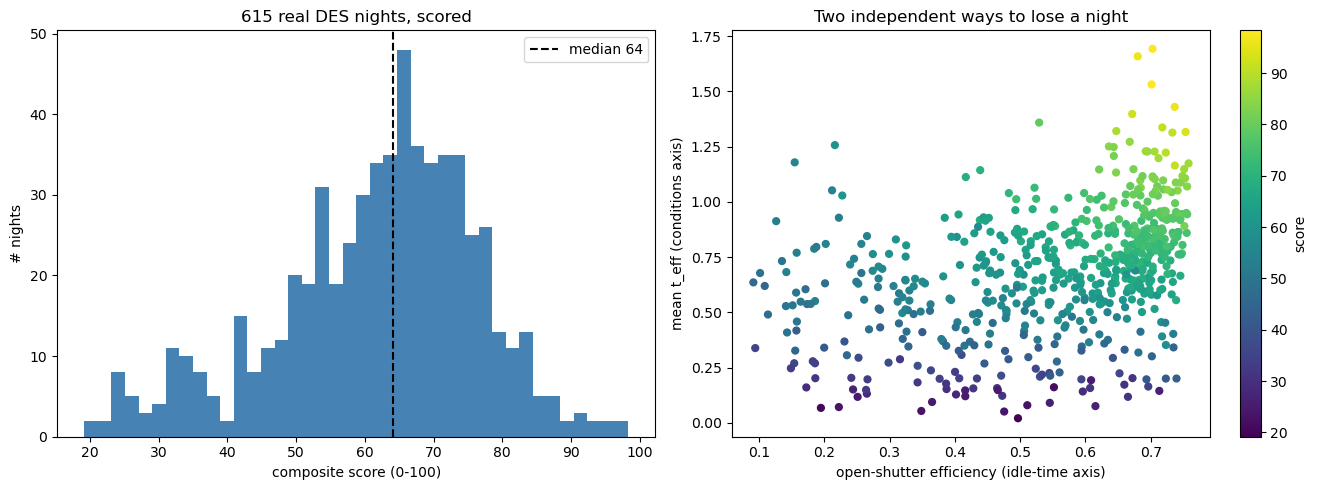

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

axes[0].hist(nights['score'], bins=40, color='steelblue')
axes[0].axvline(nights['score'].median(), color='k', ls='--',
                label=f"median {nights['score'].median():.0f}")
axes[0].set_xlabel('composite score (0-100)'); axes[0].set_ylabel('# nights')
axes[0].set_title('615 real DES nights, scored'); axes[0].legend()

sc = axes[1].scatter(nights['open_shutter_efficiency'], nights['mean_teff'],
                     c=nights['score'], cmap='viridis', s=24)
axes[1].set_xlabel('open-shutter efficiency (idle-time axis)')
axes[1].set_ylabel('mean t_eff (conditions axis)')
axes[1].set_title('Two independent ways to lose a night')
fig.colorbar(sc, ax=axes[1], label='score')
plt.tight_layout(); plt.show()

The scatter confirms the decomposition is *diagnostic*: nights in the lower-right ran efficiently through bad conditions (nothing a scheduler could do); nights in the upper-left had good sky but wasted clock time (very much the scheduler's business).

## Anatomy of the best and worst nights

In [3]:
best_id, worst_id = nights['score'].idxmax(), nights['score'].idxmin()
display_cols = ['n_exposures','open_shutter_efficiency','mean_teff','effective_efficiency',
                'pass_fraction','median_airmass','median_fwhm','median_cloud','score']
pd.concat([nights.loc[[best_id]], nights.loc[[worst_id]]])[display_cols].round(3)

,n_exposures,open_shutter_efficiency,mean_teff,effective_efficiency,pass_fraction,median_airmass,median_fwhm,median_cloud,score
night,,,,,,,,,
2019-01-08,34,0.703,1.693,1.19,1.0,1.055,0.80,0.025,98.340
2018-09-11,24,0.497,0.021,0.01,0.0,1.310,1.01,2.400,19.154


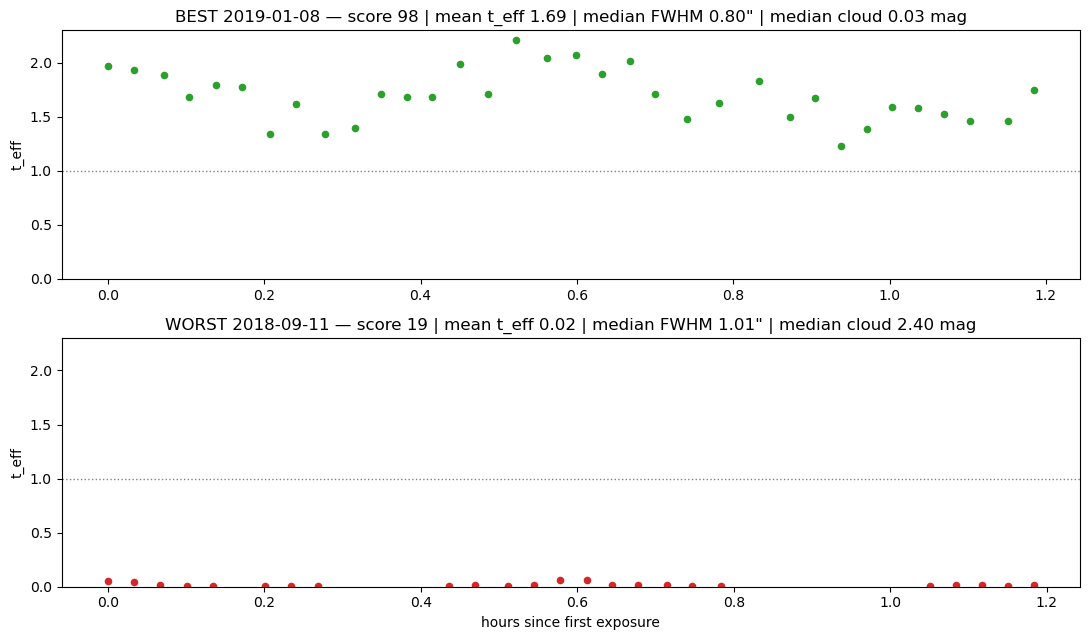

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
for ax, nid, color, tag in [(axes[0], best_id, 'tab:green', 'BEST'),
                            (axes[1], worst_id, 'tab:red', 'WORST')]:
    g = f[f['night'] == nid].sort_values('dt')
    hours = (g['dt'] - g['dt'].min()).dt.total_seconds()/3600
    ax.scatter(hours, g['teff'], s=20, color=color)
    ax.axhline(1.0, color='gray', ls=':', lw=1)
    ax.set_ylabel('t_eff'); ax.set_ylim(0, 2.3)
    m = nights.loc[nid]
    ax.set_title(f"{tag} {nid} — score {m['score']:.0f} | mean t_eff {m['mean_teff']:.2f} | "
                 f"median FWHM {m['median_fwhm']:.2f}\" | median cloud {m['median_cloud']:.2f} mag")
axes[1].set_xlabel('hours since first exposure')
plt.tight_layout(); plt.show()

The metric reads the *cause* straight off the sub-metrics: the worst night has heavy cloud extinction (`median_cloud` in magnitudes) — every exposure was nearly worthless regardless of scheduling. The best night ran at $t_{\rm eff}\approx1.7$: conditions *better than fiducial* (sharp, dark, photometric), so every clock second paid ~1.7×.

## Did DES's scheduling get better over the years?

The DES team continuously tuned their tactical scheduler (obstac). If our metric is measuring something real, later seasons should score better.

In [5]:
nn = nights.reset_index()
nn['night_dt'] = pd.to_datetime(nn['night'])
# DES seasons run Aug-Feb; label each season by its starting year
nn['season'] = np.where(nn['night_dt'].dt.month >= 8,
                        nn['night_dt'].dt.year, nn['night_dt'].dt.year - 1)
by_season = nn.groupby('season').agg(
    nights=('score','size'), median_score=('score','median'),
    median_yield=('effective_efficiency','median'),
    median_open_shutter=('open_shutter_efficiency','median')).round(3)
by_season

,nights,median_score,median_yield,median_open_shutter
season,,,,
2013,90,61.384,0.346,0.584
2014,111,62.157,0.361,0.592
2015,99,57.957,0.282,0.544
2016,123,65.855,0.419,0.575
2017,129,68.614,0.465,0.643
2018,63,68.165,0.441,0.643


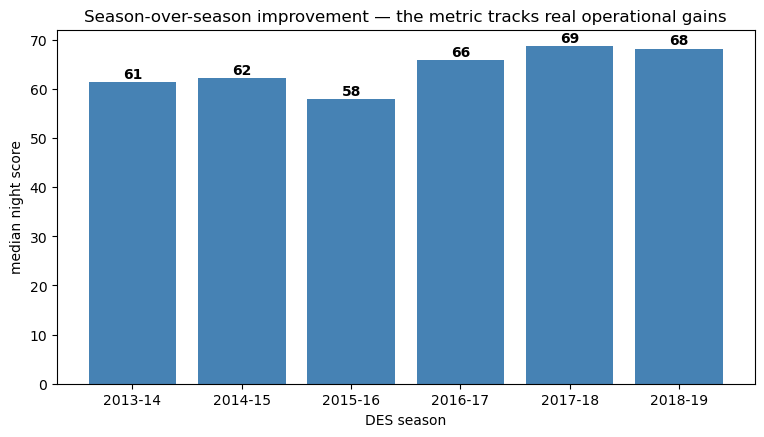

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.6))
seasons = by_season.index.astype(str) + '-' + (by_season.index+1).astype(str).str[2:]
ax.bar(seasons, by_season['median_score'], color='steelblue')
for i, v in enumerate(by_season['median_score']):
    ax.text(i, v+0.8, f'{v:.0f}', ha='center', fontweight='bold')
ax.set_ylabel('median night score'); ax.set_xlabel('DES season')
ax.set_title('Season-over-season improvement — the metric tracks real operational gains')
plt.show()

## Is the ranking robust to the weights?

A composite score is only useful if reasonable people with different weights would still agree which nights were good. Vary the weights and check the rank correlation:

In [7]:
from scipy.stats import spearmanr

base = composite_score(nights)
alternatives = {
    'yield-heavy (0.8/0.1/0.1)':   dict(weights={'yield':.8,'quality':.1,'pointing':.1}),
    'quality-heavy (0.2/0.6/0.2)': dict(weights={'yield':.2,'quality':.6,'pointing':.2}),
    'pointing-heavy (0.2/0.2/0.6)':dict(weights={'yield':.2,'quality':.2,'pointing':.6}),
    'equal (1/3 each)':            dict(weights={'yield':1/3,'quality':1/3,'pointing':1/3}),
}
for name, kw in alternatives.items():
    alt = composite_score(nights, **kw)
    rho = spearmanr(base, alt).statistic
    print(f'{name:32s} Spearman rank corr with v0.1 weights: {rho:.3f}')

yield-heavy (0.8/0.1/0.1)        Spearman rank corr with v0.1 weights: 0.992
quality-heavy (0.2/0.6/0.2)      Spearman rank corr with v0.1 weights: 0.980
pointing-heavy (0.2/0.2/0.6)     Spearman rank corr with v0.1 weights: 0.836
equal (1/3 each)                 Spearman rank corr with v0.1 weights: 0.991


High rank correlations mean the *ordering* of nights is driven by the data, not by our weight choices — with the expected exception that a pointing-heavy score measures a genuinely different (scheduler-only) notion of quality. That's a feature: report `pointing` alongside the composite.

## Takeaways & where this goes

1. **A schedule metric exists and runs end-to-end on real data**: `night_metrics` + `composite_score` scored 615 DES nights, and the results are interpretable (cause-of-loss diagnosis) and robust (rank-stable under weight changes).
2. **It detects real operational improvement** across DES seasons — evidence the metric measures scheduling quality, not just weather luck.
3. **The pointing sub-score is the fair one for AI-scheduler comparisons** — it isolates decisions from conditions (notebook 02's selection-bias lesson).
4. **Next steps** (to bring to mentors):
   - agree on weights / thresholds, and per-program handling (survey vs supernova vs GW follow-up have different goals),
   - add slew-time modeling so dead time can be attributed (slew vs weather closure),
   - run these metrics on the *prototype AI scheduler's* output and compare against DES baseline nights under matched conditions,
   - use $t_{\rm eff}\cdot\tau$ (and/or the pointing sub-score) as the reward for offline RL (CQL) training.